### Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

print("=== 1. INTEGRASI DATA HISTORIS (FARM) & DATA LIVE (API) ===\n")

# 1. Mount Google Drive
drive.mount('/content/drive')

path_farm = '/content/drive/MyDrive/Colab Notebooks/Smart Farming Sensor Data for Yield Prediction/Smart_Farming_Crop_Yield_2024.csv'
path_api = '/content/drive/MyDrive/Colab Notebooks/Smart Farming Sensor Data for Yield Prediction/API_indo_Temperature_Soil_Temperature,Soil_Moisture.csv'

# 2. Membaca Kedua Data
df_farm = pd.read_csv(path_farm)
df_api = pd.read_csv(path_api, skiprows=3)

# 3. MENGOLAH DATA BELAJAR (SMART FARMING)
df_farm['Status_Tanaman'] = np.where(df_farm['yield_kg_per_hectare'] < 3000, 0, 1)

# Kita ambil fitur yang sama dengan API
X_train_farm = df_farm[['temperature_C', 'soil_moisture_%']]
y_train_farm = df_farm['Status_Tanaman']

# 4. MENGOLAH DATA LIVE (API OPEN-METEO)
df_api['time'] = pd.to_datetime(df_api['time'])
df_api['soil_moisture_%'] = df_api['soil_moisture_3_to_9cm (m³/m³)'] * 100
df_api['temperature_C'] = df_api['temperature_2m (°C)']

X_live_api = df_api[['temperature_C', 'soil_moisture_%']]

print("[+] Dataset Berhasil Disatukan & Disinkronisasi!")
print(f"Data Belajar (Farm): {len(df_farm)} baris")
print(f"Data Live (API)    : {len(df_api)} jam\n")

=== 1. INTEGRASI DATA HISTORIS (FARM) & DATA LIVE (API) ===

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[+] Dataset Berhasil Disatukan & Disinkronisasi!
Data Belajar (Farm): 500 baris
Data Live (API)    : 168 jam



### Model Isolation Forest

=== 2. ISOLATION FOREST  ===



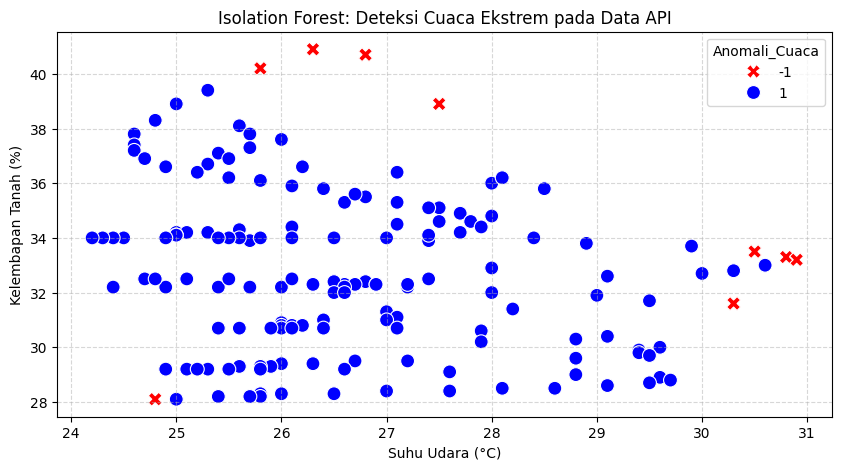

Isolation Forest mendeteksi 9 titik cuaca ekstrem dari Open-Meteo yang menyimpang dari tren normal mingguan.


In [ ]:
from sklearn.ensemble import IsolationForest

print("=== 2. ISOLATION FOREST  ===\n")

# Latih Isolation forest LANGSUNG menggunakan data cuaca API saat ini
iso_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_api['Anomali_Cuaca'] = iso_model.fit_predict(X_live_api)
df_api

# Visualisasi Cuaca dari API
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_api, x='temperature_C', y='soil_moisture_%',
                hue='Anomali_Cuaca', palette={1: 'blue', -1: 'red'},
                style='Anomali_Cuaca', markers={1: 'o', -1: 'X'}, s=100)

plt.title("Isolation Forest: Deteksi Cuaca Ekstrem pada Data API")
plt.xlabel("Suhu Udara (°C)")
plt.ylabel("Kelembapan Tanah (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Isolation Forest mendeteksi {len(df_api[df_api['Anomali_Cuaca'] == -1])} titik cuaca ekstrem dari Open-Meteo yang menyimpang dari tren normal mingguan.")

### Model Decision Tree

=== 3. DECISION TREE ===



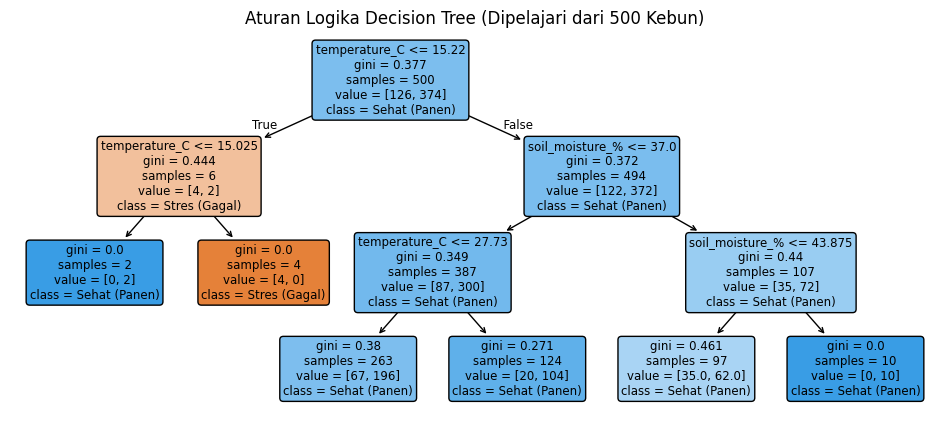

Penjelasan: Berdasarkan data 500 kebun, Decision Tree memprediksi ada 0 jam di minggu ini (data API) di mana cuaca berpotensi merusak tanaman.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("=== 3. DECISION TREE ===\n")

# 1. Belajar dari Rapor Masa Lalu (Smart Farming)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_farm, y_train_farm)

# 2. Praktek Langsung ke Data API Cuaca Hari ini!
df_api['Prediksi_Tree'] = tree_model.predict(X_live_api)

# 3. Menggambar Aturan yang Dibuat AI
plt.figure(figsize=(12, 5))
plot_tree(tree_model, feature_names=X_train_farm.columns, class_names=['Stres (Gagal)', 'Sehat (Panen)'], filled=True, rounded=True)
plt.title("Aturan Logika Decision Tree (Dipelajari dari 500 Kebun)")
plt.show()

# Berapa jam tanaman mengalami stres minggu ini?
stres_tree = len(df_api[df_api['Prediksi_Tree'] == 0])
print(f"Penjelasan: Berdasarkan data 500 kebun, Decision Tree memprediksi ada {stres_tree} jam di minggu ini (data API) di mana cuaca berpotensi merusak tanaman.")

### Model Gradient Boosting

=== 4. GRADIENT BOOSTING (Prediksi Super Akurat) ===



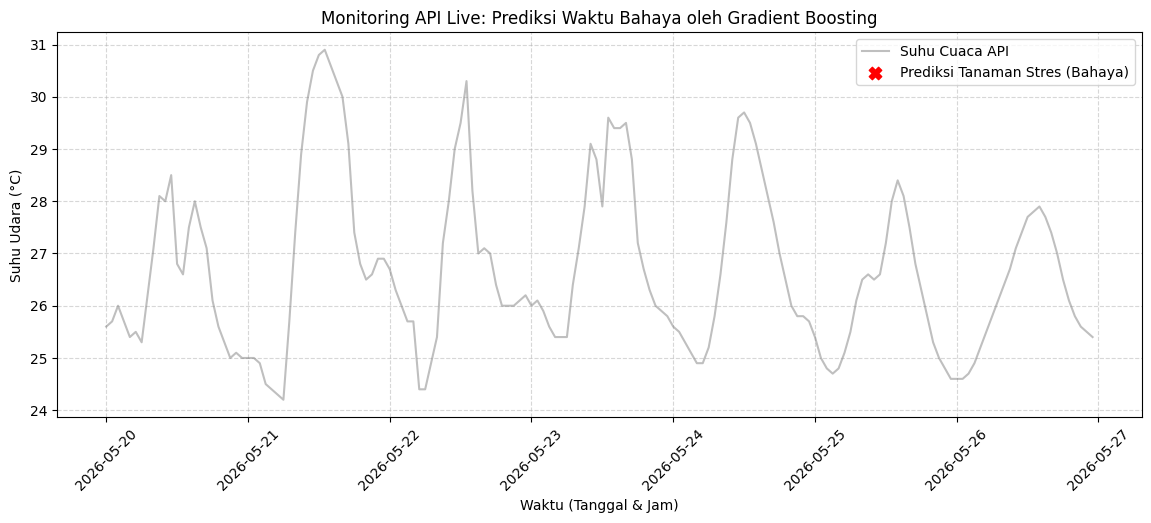

Penjelasan: Gradient Boosting memprediksi tanaman akan mengalami stres selama 0 jam pada minggu ini. Grafik di atas menunjukkan waktu tepatnya (Tanda Silang Merah).


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print("=== 4. GRADIENT BOOSTING (Prediksi Super Akurat) ===\n")

# 1. Belajar dari Rapor Masa Lalu menggunakan 100 pohon
boost_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
boost_model.fit(X_train_farm, y_train_farm)

# 2. Prediksi kondisi tanaman di cuaca API hari ini
df_api['Prediksi_Boost'] = boost_model.predict(X_live_api)

# 3. Menampilkan grafik Kapan Tanaman Diprediksi Stres Sepanjang Minggu
plt.figure(figsize=(14, 5))

# Plot cuaca (Suhu)
sns.lineplot(data=df_api, x='time', y='temperature_C', color='gray', label='Suhu Cuaca API', alpha=0.5)

# Tandai titik merah saat algoritma Boosting memprediksi Tanaman Stres
titik_bahaya = df_api[df_api['Prediksi_Boost'] == 0]
plt.scatter(titik_bahaya['time'], titik_bahaya['temperature_C'], color='red', s=80, marker='X', zorder=5, label='Prediksi Tanaman Stres (Bahaya)')

plt.title("Monitoring API Live: Prediksi Waktu Bahaya oleh Gradient Boosting")
plt.xlabel("Waktu (Tanggal & Jam)")
plt.ylabel("Suhu Udara (°C)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

stres_boost = len(titik_bahaya)
print(f"Penjelasan: Gradient Boosting memprediksi tanaman akan mengalami stres selama {stres_boost} jam pada minggu ini. Grafik di atas menunjukkan waktu tepatnya (Tanda Silang Merah).")

=== 5. SIMULASI PETA PANAS (SPATIAL HEATMAP) MULTI-NODE ===



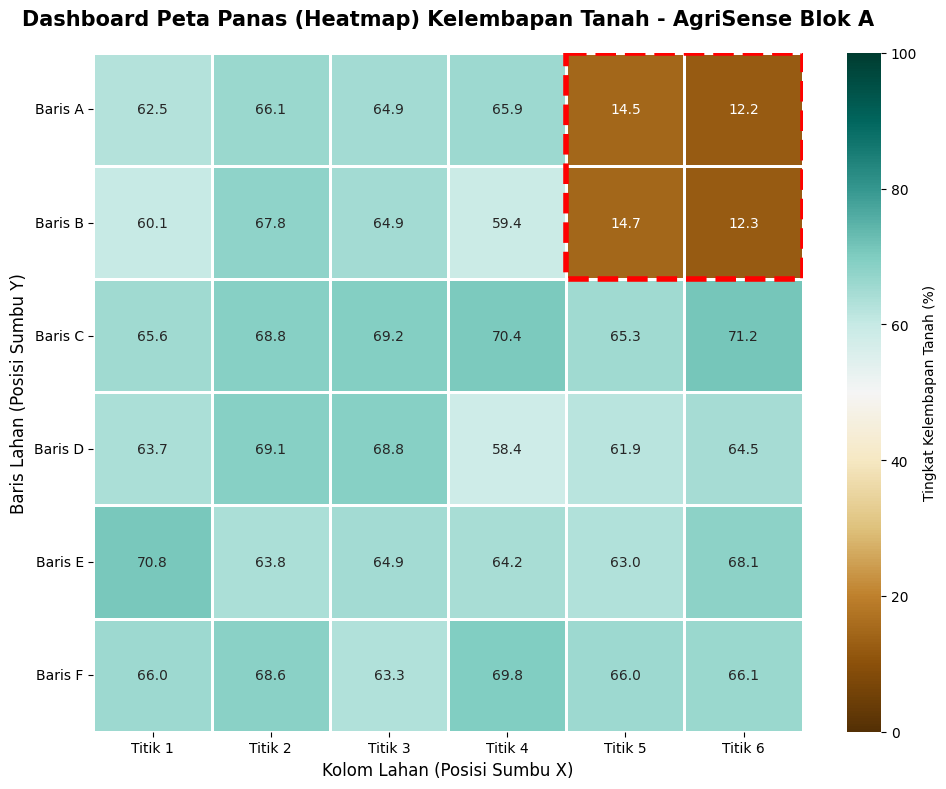


[!] PERINGATAN SISTEM: Ditemukan area dengan kelembapan tanah Kritis (< 20%)
Lokasi: Baris A-B, Titik 5-6 (Ditandai dengan kotak putus-putus merah).
Tindakan Disarankan: Segera cek pompa irigasi atau kebocoran selang di koordinat tersebut!


In [ ]:
print("=== 5. SIMULASI PETA PANAS (SPATIAL HEATMAP) MULTI-NODE ===\n")

# 1. GRID LAHAN (simulasi di lengkapi 36 Sensor IoT di Blok A)
# Membuat kondisi normal: Kelembapan tanah rata-rata 65% (Bagus & Cukup Air)
grid_ukuran = 6
kelembapan_lahan = np.random.normal(loc=65, scale=4, size=(grid_ukuran, grid_ukuran))

# 2. INJEKSI ANOMALI (BENCANA KEKERINGAN LOKAL)
# Skenario: Selang irigasi tersumbat di pojok Kanan Atas (Baris 0-1, Kolom 4-5)
# Tanah di area ini mengering drastis menjadi sekitar 15%
kelembapan_lahan[0:2, 4:6] = np.random.normal(loc=15, scale=2, size=(2, 2))

# 3. VISUALISASI PETA PANAS (HEATMAP)
plt.figure(figsize=(10, 8))

# Membuat Heatmap dengan Seaborn
# cmap="BrBG" akan otomatis membuat warna Cokelat (Kering) hingga Hijau-Kebiruan (Basah)
ax = sns.heatmap(
    kelembapan_lahan,
    annot=True,               # Menampilkan angka persentase di tiap petak
    fmt=".1f",                # Format 1 angka di belakang koma
    cmap="BrBG",              # Skema warna bawaan (Brown to Green)
    vmin=0, vmax=100,         # Batas indikator 0% - 100%
    linewidths=2,             # Garis pembatas antar petak
    cbar_kws={'label': 'Tingkat Kelembapan Tanah (%)'}
)

# Menambahkan kotak merah tebal pada area anomali menggunakan fungsi bawaan plt
kotak_bahaya = plt.Rectangle((4, 0), 2, 2, fill=False, edgecolor='red', lw=4, linestyle='--')
ax.add_patch(kotak_bahaya)

plt.title("Dashboard Peta Panas (Heatmap) Kelembapan Tanah - AgriSense Blok A", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Kolom Lahan (Posisi Sumbu X)", fontsize=12)
plt.ylabel("Baris Lahan (Posisi Sumbu Y)", fontsize=12)

# Mengubah label agar lebih mirip posisi koordinat nyata di lapangan
plt.xticks(np.arange(6) + 0.5, ['Titik 1', 'Titik 2', 'Titik 3', 'Titik 4', 'Titik 5', 'Titik 6'])
plt.yticks(np.arange(6) + 0.5, ['Baris A', 'Baris B', 'Baris C', 'Baris D', 'Baris E', 'Baris F'], rotation=0)

plt.tight_layout()
plt.show()

# 4. LOG PERINGATAN SISTEM
print("\n[!] PERINGATAN SISTEM: Ditemukan area dengan kelembapan tanah Kritis (< 20%)")
print("Lokasi: Baris A-B, Titik 5-6 (Ditandai dengan kotak putus-putus merah).")
print("Tindakan Disarankan: Segera cek pompa irigasi atau kebocoran selang di koordinat tersebut!")

=== 6. YIELD PREDICTION (Prediksi Tonase Panen Masa Depan) ===



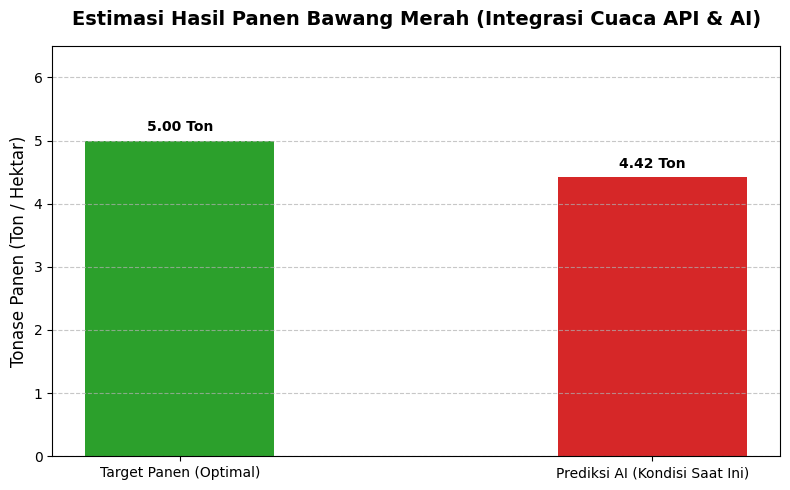


📱 NOTIFIKASI SMARTPHONE: AGRISENSE YIELD PREDICTION
⚠️ PERINGATAN: Tren cuaca saat ini (Suhu 26.7°C, Kelembapan 32.7%) kurang ideal.
Estimasi panen Blok A bulan depan adalah 4.42 Ton/Hektar.
Angka ini turun 11.6% dari target operasional.
Tindakan: Segera periksa cadangan air irigasi atau atur strategi harga jual sejak dini.


In [ ]:
# Karena sebelumnya kita hanya memanggil model untuk kategori (Classifier),
# kita butuh 1 baris import khusus untuk model penebak angka (Regressor)
from sklearn.ensemble import RandomForestRegressor

print("=== 6. YIELD PREDICTION (Prediksi Tonase Panen Masa Depan) ===\n")

# =====================================================================
# 1. BELAJAR DARI DATA HISTORIS (SMART FARMING)
# =====================================================================
# Fitur: Suhu dan Kelembapan Tanah
# Target: Angka absolut hasil panen (yield_kg_per_hectare)
X_reg = df_farm[['temperature_C', 'soil_moisture_%']]
y_reg = df_farm['yield_kg_per_hectare']

# Melatih Model Random Forest Regressor (Model ini kebal terhadap fluktuasi ekstrem)
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_reg, y_reg)

# =====================================================================
# 2. MENGANALISIS TREN CUACA TERKINI (DARI API LIVE)
# =====================================================================
# Sistem membaca tren cuaca minggu ini dari Open-Meteo
suhu_rata2_api = df_api['temperature_C'].mean()
kelembapan_rata2_api = df_api['soil_moisture_%'].mean()

# Memasukkan ke format tabel sementara agar bisa dibaca oleh AI
kondisi_terkini = pd.DataFrame({
    'temperature_C': [suhu_rata2_api],
    'soil_moisture_%': [kelembapan_rata2_api]
})

# =====================================================================
# 3. MELAKUKAN PREDIKSI PANEN
# =====================================================================
# AI menebak hasil panen bawang merah jika cuacanya terus seperti ini
prediksi_panen_kg = rf_regressor.predict(kondisi_terkini)[0]
prediksi_panen_ton = prediksi_panen_kg / 1000  # Konversi dari Kg ke Ton

target_panen_ton = 5.0 # Asumsi target panen optimal adalah 5 Ton/Hektar
selisih = prediksi_panen_ton - target_panen_ton
persentase_selisih = (selisih / target_panen_ton) * 100

# =====================================================================
# 4. VISUALISASI DASHBOARD
# =====================================================================
plt.figure(figsize=(8, 5))
kategori = ['Target Panen (Optimal)', 'Prediksi AI (Kondisi Saat Ini)']
nilai = [target_panen_ton, prediksi_panen_ton]

# Warnai merah jika di bawah target, biru jika aman
warna = ['#2ca02c', '#d62728' if prediksi_panen_ton < target_panen_ton else '#1f77b4']

bars = plt.bar(kategori, nilai, color=warna, width=0.4)

# Menambahkan label angka di atas grafik batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f} Ton", ha='center', va='bottom', fontweight='bold')

plt.title("Estimasi Hasil Panen Bawang Merah (Integrasi Cuaca API & AI)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Tonase Panen (Ton / Hektar)", fontsize=12)
plt.ylim(0, max(target_panen_ton, prediksi_panen_ton) + 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. SIMULASI NOTIFIKASI APLIKASI (UI)
# =====================================================================
print("\n" + "="*70)
print(" NOTIFIKASI SMARTPHONE: AGRISENSE YIELD PREDICTION")
print("="*70)

if prediksi_panen_ton < target_panen_ton:
    print(f" PERINGATAN: Tren cuaca saat ini (Suhu {suhu_rata2_api:.1f}°C, Kelembapan {kelembapan_rata2_api:.1f}%) kurang ideal.")
    print(f"Estimasi panen Blok A bulan depan adalah {prediksi_panen_ton:.2f} Ton/Hektar.")
    print(f"Angka ini turun {abs(persentase_selisih):.1f}% dari target operasional.")
    print("Tindakan: Segera periksa cadangan air irigasi atau atur strategi harga jual sejak dini.")
else:
    print(f" KABAR BAIK: Kondisi cuaca sangat mendukung (Suhu {suhu_rata2_api:.1f}°C, Kelembapan {kelembapan_rata2_api:.1f}%).")
    print(f"Estimasi panen Blok A bulan depan adalah {prediksi_panen_ton:.2f} Ton/Hektar.")
    print(f"Ini melampaui target sebesar {persentase_selisih:.1f}%. Pertahankan rutinitas pemeliharaan lahan!")
print("="*70)